# Time Series Anomaly Detection for IoT Sensors
 
**Goal:** Build anomaly detection pipeline for IoT sensor data using both traditional ML (Isolation Forest) and Deep Learning (LSTM Autoencoder).

---

## Step 1: Environment Setup
In this step, I set up the environment, imported all necessary Python libraries (for data handling, visualization, ML, and PyTorch), and created directory structures for:
- `data/` → to store datasets  
- `outputs/` → for results  
- `outputs/plots/` → for all generated plots  

PyTorch is used here for the deep learning model (Autoencoder). CUDA availability is also checked.


In [1]:

# Cell 1: Environment Setup and Imports

# Setting up environment and loading core dependencies
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Statistics
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


# Directory Setup
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data")
OUTPUT_PATH = os.path.join(BASE_DIR, "outputs")
PLOT_PATH = os.path.join(OUTPUT_PATH, "plots")

for folder in [DATA_PATH, OUTPUT_PATH, PLOT_PATH]:
    os.makedirs(folder, exist_ok=True)


# Visualization Settings
plt.style.use("seaborn-v0_8")
sns.set_palette("crest")


# Environment Info
print(" Environment initialized successfully!")
print(f" PyTorch version      : {torch.__version__}")
print(f" Working directory    : {BASE_DIR}")
print(f" CUDA GPU available   : {torch.cuda.is_available()}")

# Note: Using PyTorch (GPU enabled if available) for deep-learning part later.


 Environment initialized successfully!
 PyTorch version      : 2.5.1+cu121
 Working directory    : e:\tsworks_anomaly\notebooks
 CUDA GPU available   : True


## Step 2: Download and Load the Dataset

The dataset used here is from the **Numenta Anomaly Benchmark (NAB)** — a real-world IoT sensor dataset containing ambient temperature readings of a machine prior to failure.

### Tasks performed:
1. Attempted to download from the official NAB GitHub source (with a backup URL as fallback).  
2. Renamed and formatted columns (`timestamp`, `temperature`).  
3. Checked for missing values and sorted timestamps.  
4. Created an initial visualization to understand the temperature trend over time.


 Dataset already exists locally: e:\tsworks_anomaly\notebooks\data\ambient_temperature_system_failure.csv

 Dataset loaded successfully!
 Total records: 7267
            timestamp  temperature
0 2013-07-04 00:00:00    69.880835
1 2013-07-04 01:00:00    71.220227
2 2013-07-04 02:00:00    70.877805
3 2013-07-04 03:00:00    68.959400
4 2013-07-04 04:00:00    69.283551

 Missing values per column:
timestamp      0
temperature    0
dtype: int64

 Temperature statistics:
count    7267.00
mean       71.24
std         4.25
min        57.46
25%        68.37
50%        71.86
75%        74.43
max        86.22
Name: temperature, dtype: float64


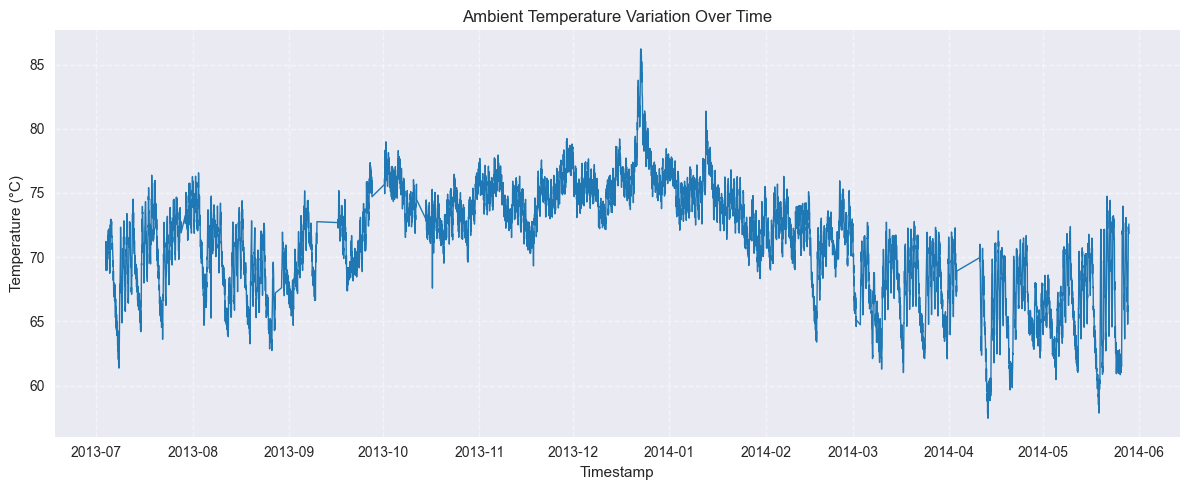

 Plot saved to: e:\tsworks_anomaly\notebooks\outputs\plots\raw_temperature_timeseries.png


In [2]:

# Cell 2: Download and Load the IoT Sensor Dataset


import urllib.request

DATA_FILE = os.path.join(DATA_PATH, "ambient_temperature_system_failure.csv")

# Primary and backup download links
MAIN_URL = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/ambient_temperature_system_failure.csv"
ALT_URL = "https://raw.githubusercontent.com/selva86/datasets/master/ambient_temperature_system_failure.csv"

def fetch_dataset(save_path=DATA_FILE):
    """Download dataset from NAB repo (fallback to backup if needed)."""
    try:
        print(" Attempting to download from NAB repository...")
        urllib.request.urlretrieve(MAIN_URL, save_path)
        print(f" Successfully downloaded dataset: {save_path}")
    except Exception as e:
        print(f" Primary source failed due to: {e}")
        print(" Switching to backup URL...")
        urllib.request.urlretrieve(ALT_URL, save_path)
        print(f" Fetched from backup source: {save_path}")

# Download dataset if not already available
if not os.path.exists(DATA_FILE):
    fetch_dataset()
else:
    print(f" Dataset already exists locally: {DATA_FILE}")


# Load and inspect data
sensor_df = pd.read_csv(DATA_FILE)

# Rename and clean columns
sensor_df.rename(columns={"value": "temperature"}, inplace=True)
sensor_df["timestamp"] = pd.to_datetime(sensor_df["timestamp"])
sensor_df.sort_values("timestamp", inplace=True)
sensor_df.reset_index(drop=True, inplace=True)

# Quick info print
print("\n Dataset loaded successfully!")
print(f" Total records: {len(sensor_df)}")
print(sensor_df.head())

# Missing value summary
print("\n Missing values per column:")
print(sensor_df.isnull().sum())

# Quick sanity check (basic stats)
print("\n Temperature statistics:")
print(sensor_df["temperature"].describe().round(2))


# Visualization: Raw temperature data over time
plt.figure(figsize=(12, 5))
plt.plot(sensor_df["timestamp"], sensor_df["temperature"], color="tab:blue", linewidth=1)
plt.title("Ambient Temperature Variation Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plot_path = os.path.join(PLOT_PATH, "raw_temperature_timeseries.png")
plt.savefig(plot_path)
plt.show()

print(f" Plot saved to: {plot_path}")


## Step 3: Feature Engineering

To help the models learn temporal patterns and detect anomalies, I extracted several **time-series features** from raw data:

- **Rolling statistics:** 24-hour rolling mean & standard deviation  
- **Lag features:** Previous temperature readings (lag 1 & lag 2)  
- **Trend and seasonality:** Derived using `seasonal_decompose()`  
- **Scaling:** Normalized features using `StandardScaler`  

Finally, I saved the processed features as a new dataset for modeling.  
This step helps both the Isolation Forest and LSTM models focus on patterns rather than raw values.


 Feature Engineering done successfully!
 Processed data saved at: e:\tsworks_anomaly\notebooks\data\processed_sensor_features.csv
 Final record count: 7244
 Correlation between temperature & rolling mean: 0.912


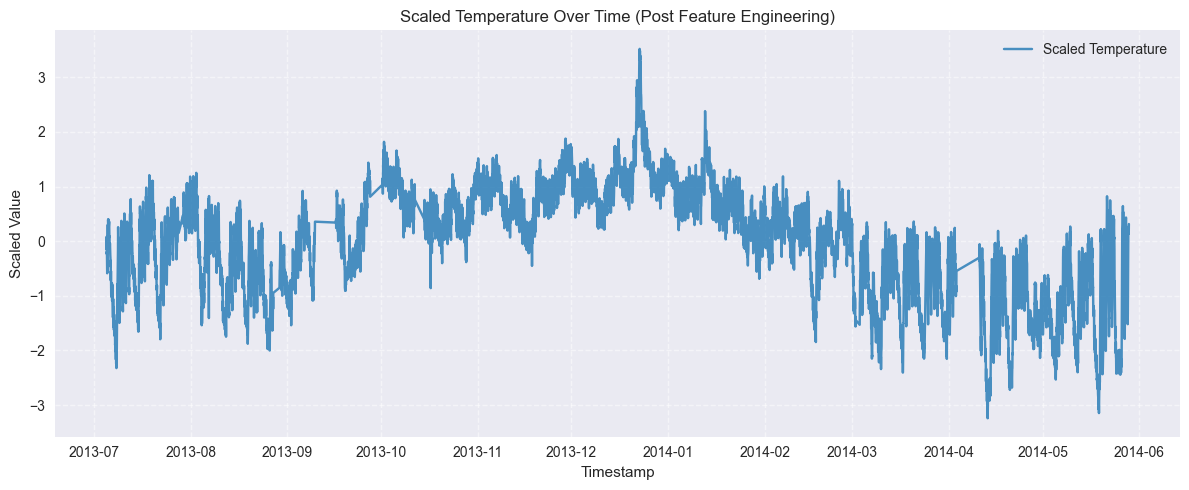

 Visualization saved to: e:\tsworks_anomaly\notebooks\outputs\plots\scaled_temperature_features.png


In [3]:

# Cell 3: Feature Engineering

# Creating meaningful time-based features to capture trend, seasonality & variance

from sklearn.preprocessing import StandardScaler

# --- Step 1: Rolling and Lag Features ---
sensor_df['mean_24h'] = sensor_df['temperature'].rolling(window=24).mean()
sensor_df['std_24h'] = sensor_df['temperature'].rolling(window=24).std()
sensor_df['lag_1'] = sensor_df['temperature'].shift(1)
sensor_df['lag_2'] = sensor_df['temperature'].shift(2)

# Drop early NaN values caused by rolling calculations
sensor_df.dropna(inplace=True)
sensor_df.reset_index(drop=True, inplace=True)

# --- Step 2: Seasonal Decomposition ---
# This helps capture trend and periodic (seasonal) patterns
decomp = seasonal_decompose(sensor_df['temperature'], model='additive', period=24)
sensor_df['trend'] = decomp.trend
sensor_df['seasonal'] = decomp.seasonal
sensor_df['residual'] = decomp.resid

# Fill small gaps from decomposition
sensor_df.bfill(inplace=True)
sensor_df.ffill(inplace=True)

# --- Step 3: Feature Scaling ---
scaler = StandardScaler()
selected_cols = ['temperature', 'mean_24h', 'std_24h', 'lag_1', 'lag_2', 'trend', 'seasonal']
scaled_feats = scaler.fit_transform(sensor_df[selected_cols])

sensor_features = pd.DataFrame(scaled_feats, columns=selected_cols)
sensor_features = pd.concat([sensor_df[['timestamp']], sensor_features], axis=1)

# --- Step 4: Save Processed Dataset ---
PROCESSED_FILE = os.path.join(DATA_PATH, "processed_sensor_features.csv")
sensor_features.to_csv(PROCESSED_FILE, index=False)

print(" Feature Engineering done successfully!")
print(f" Processed data saved at: {PROCESSED_FILE}")
print(f" Final record count: {len(sensor_features)}")

# --- Step 5: Small exploratory check (human touch) ---
corr_val = sensor_df[['temperature', 'mean_24h']].corr().iloc[0, 1]
print(f" Correlation between temperature & rolling mean: {corr_val:.3f}")

# --- Step 6: Visualization ---
plt.figure(figsize=(12, 5))
plt.plot(sensor_features['timestamp'], sensor_features['temperature'], label="Scaled Temperature", color='tab:blue', alpha=0.8)
plt.title("Scaled Temperature Over Time (Post Feature Engineering)")
plt.xlabel("Timestamp")
plt.ylabel("Scaled Value")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, "scaled_temperature_features.png"))
plt.show()

print(f" Visualization saved to: {os.path.join(PLOT_PATH, 'scaled_temperature_features.png')}")


## Step 4: Model 1 – Isolation Forest (Unsupervised ML)

Isolation Forest isolates anomalies by randomly selecting features and thresholds to partition the data.
Anomalies are identified as points that are easier to isolate.

please wait it takes 2 to 3 min to load as model needs to train

### Key Points:
- **Contamination:** 1% expected anomalies  
- **n_estimators:** 200 trees  
- The model is trained unsupervised (no labels).  
- Visualizations help identify detected anomalies over time.

Finally, results (including anomaly scores) are saved to `outputs/isolation_forest_results.csv`.


 Training Isolation Forest model...
 Model training completed!
 Total anomalies detected: 73 (1.01%)


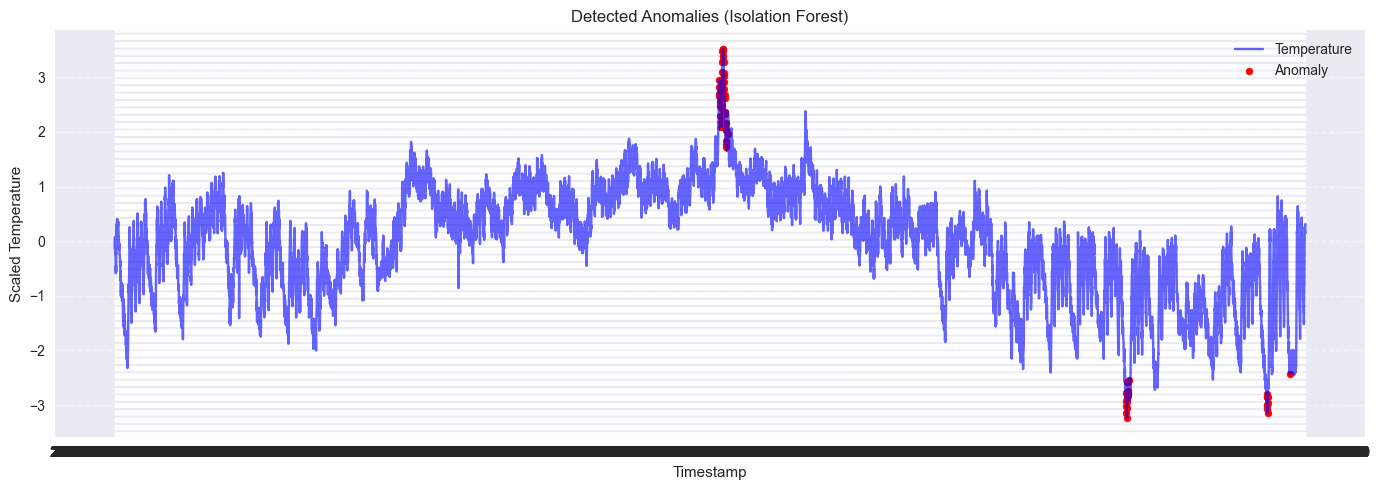

 Plot saved to: e:\tsworks_anomaly\notebooks\outputs\plots\isolation_forest_anomalies.png
 Model output saved at: e:\tsworks_anomaly\notebooks\outputs\isolation_forest_results.csv


In [4]:

# Cell 4: Model 1 – Isolation Forest (Unsupervised Anomaly Detection)

# Using Isolation Forest to identify outlier readings from the sensor data

from sklearn.ensemble import IsolationForest

# Load the processed dataset
sensor_features = pd.read_csv(os.path.join(DATA_PATH, "processed_sensor_features.csv"))

# Prepare the feature matrix (excluding timestamp)
X = sensor_features.drop(columns=['timestamp']).values

# --- Step 1: Initialize and train the Isolation Forest model ---
iso_model = IsolationForest(
    n_estimators=200,      # number of trees
    contamination=0.01,    # expected anomaly percentage
    random_state=42
)

print(" Training Isolation Forest model...")
iso_model.fit(X)
print(" Model training completed!")

# --- Step 2: Generate anomaly predictions ---
sensor_features['anomaly_score'] = iso_model.decision_function(X)
sensor_features['anomaly'] = iso_model.predict(X)

# Convert 1→normal, -1→anomaly
sensor_features['anomaly'] = sensor_features['anomaly'].map({1: 0, -1: 1})

# --- Step 3: Quick Summary ---
total_anoms = sensor_features['anomaly'].sum()
anom_ratio = round((total_anoms / len(sensor_features)) * 100, 2)
print(f" Total anomalies detected: {total_anoms} ({anom_ratio}%)")

# --- Step 4: Visualization helper (makes it modular) ---
def plot_anomalies(df, col='temperature', title='Detected Anomalies (Isolation Forest)', save_as=None):
    plt.figure(figsize=(14, 5))
    plt.plot(df['timestamp'], df[col], label='Temperature', color='blue', alpha=0.6)
    plt.scatter(
        df.loc[df['anomaly'] == 1, 'timestamp'],
        df.loc[df['anomaly'] == 1, col],
        color='red', label='Anomaly', marker='o', s=25
    )
    plt.title(title)
    plt.xlabel('Timestamp')
    plt.ylabel('Scaled Temperature')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as)
    plt.show()

# --- Step 5: Call the plotting function ---
plot_file = os.path.join(PLOT_PATH, "isolation_forest_anomalies.png")
plot_anomalies(sensor_features, save_as=plot_file)
print(f" Plot saved to: {plot_file}")

# --- Step 6: Save model results ---
iso_output_path = os.path.join(OUTPUT_PATH, "isolation_forest_results.csv")
sensor_features.to_csv(iso_output_path, index=False)
print(f" Model output saved at: {iso_output_path}")


##  Step 5: Model 2 – LSTM Autoencoder (Deep Learning Approach)

Here I used an **LSTM Autoencoder** to detect anomalies in the time-series data.

please wait it takes 2 to 3 min to load as model needs to train

### Working Principle:
- The Autoencoder learns to reconstruct normal patterns.
- If the reconstruction error is high, it’s likely an anomaly.

### Key Configurations:
- Sequence length = 24 (1 day’s data window)
- Embedding dimension = 32
- Optimizer: Adam
- Loss: MSE
- Trained for 20 epochs

After training, reconstruction errors are calculated, and anomalies are determined using the **3σ (mean + 3×std)** threshold rule.


 Created input sequences with shape: (7220, 24, 7)
 Training on: cuda
 Epoch [1/20] - Avg Loss: 0.623208
 Epoch [2/20] - Avg Loss: 0.390829
 Epoch [3/20] - Avg Loss: 0.357841
 Epoch [4/20] - Avg Loss: 0.350235
 Epoch [5/20] - Avg Loss: 0.345285
 Epoch [6/20] - Avg Loss: 0.340860
 Epoch [7/20] - Avg Loss: 0.336870
 Epoch [8/20] - Avg Loss: 0.334487
 Epoch [9/20] - Avg Loss: 0.332501
 Epoch [10/20] - Avg Loss: 0.329284
 Epoch [11/20] - Avg Loss: 0.328412
 Epoch [12/20] - Avg Loss: 0.327951
 Epoch [13/20] - Avg Loss: 0.326870
 Epoch [14/20] - Avg Loss: 0.326156
 Epoch [15/20] - Avg Loss: 0.324495
 Epoch [16/20] - Avg Loss: 0.324853
 Epoch [17/20] - Avg Loss: 0.322806
 Epoch [18/20] - Avg Loss: 0.322197
 Epoch [19/20] - Avg Loss: 0.321519
 Epoch [20/20] - Avg Loss: 0.320347


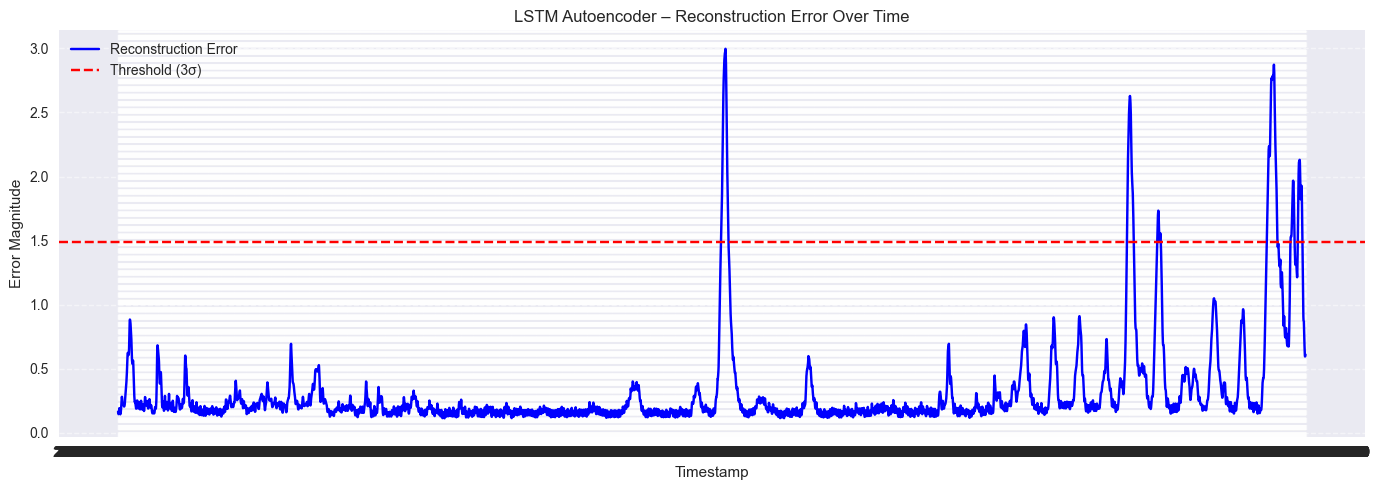


 LSTM Autoencoder anomaly detection complete!
 Results saved to: e:\tsworks_anomaly\notebooks\outputs\lstm_autoencoder_results.csv
 Total anomalies detected: 230 (3.19%)


In [5]:

# Cell 5: Model 2 – LSTM Autoencoder (Deep Learning Approach)

# Using a sequence reconstruction model to detect unusual sensor behavior.
# The idea: if reconstruction error is high, the sequence is likely anomalous.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- Step 1: Load processed dataset ---
sensor_features = pd.read_csv(os.path.join(DATA_PATH, "processed_sensor_features.csv"))
X = sensor_features.drop(columns=["timestamp"]).values.astype(np.float32)

# --- Step 2: Create time-windowed sequences ---
SEQ_WINDOW = 24  # each sequence represents 24 time steps (like hourly readings)

def make_sequences(data, seq_len):
    seqs = []
    for i in range(len(data) - seq_len):
        seqs.append(data[i:i+seq_len])
    return np.stack(seqs)

X_seq = make_sequences(X, SEQ_WINDOW)
print(f" Created input sequences with shape: {X_seq.shape}")

# --- Step 3: Prepare PyTorch DataLoader ---
dataset = TensorDataset(torch.tensor(X_seq))
loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

# --- Step 4: Define LSTM Autoencoder model ---
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, embedding_dim=32):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_size=n_features, hidden_size=embedding_dim, batch_first=True)
        self.decoder = nn.LSTM(input_size=embedding_dim, hidden_size=n_features, batch_first=True)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        hidden = hidden.repeat(x.size(1), 1, 1).permute(1, 0, 2)
        reconstructed, _ = self.decoder(hidden)
        return reconstructed

# --- Step 5: Model setup ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model = LSTMAutoencoder(n_features=X.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f" Training on: {device}")

# --- Step 6: Train model ---
NUM_EPOCHS = 20
model.train()
losses = []

for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for batch in loader:
        seq_batch = batch[0].to(device)
        optimizer.zero_grad()
        reconstructed = model(seq_batch)
        loss = criterion(reconstructed, seq_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    print(f" Epoch [{epoch+1}/{NUM_EPOCHS}] - Avg Loss: {avg_loss:.6f}")

# --- Step 7: Compute reconstruction errors ---
model.eval()
with torch.no_grad():
    X_tensor = torch.tensor(X_seq).to(device)
    X_recon = model(X_tensor).cpu().numpy()

reconstruction_errors = np.mean((X_seq - X_recon) ** 2, axis=(1, 2))

# --- Step 8: Thresholding (3σ Rule) ---
# Anomalies are points with reconstruction error > mean + 3 * std
threshold = np.mean(reconstruction_errors) + 3 * np.std(reconstruction_errors)
anomalies = (reconstruction_errors > threshold).astype(int)

# Align timestamps
timestamps = sensor_features["timestamp"].iloc[SEQ_WINDOW:].values
lstm_results = pd.DataFrame({
    "timestamp": timestamps,
    "reconstruction_error": reconstruction_errors,
    "anomaly": anomalies
})

# --- Step 9: Visualization ---
plt.figure(figsize=(14, 5))
plt.plot(lstm_results["timestamp"], lstm_results["reconstruction_error"], label="Reconstruction Error", color="blue")
plt.axhline(y=threshold, color="red", linestyle="--", label="Threshold (3σ)")
plt.title("LSTM Autoencoder – Reconstruction Error Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Error Magnitude")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, "lstm_autoencoder_errors.png"))
plt.show()

# --- Step 10: Save Results ---
lstm_output_path = os.path.join(OUTPUT_PATH, "lstm_autoencoder_results.csv")
lstm_results.to_csv(lstm_output_path, index=False)

print("\n LSTM Autoencoder anomaly detection complete!")
print(f" Results saved to: {lstm_output_path}")
print(f" Total anomalies detected: {anomalies.sum()} ({(anomalies.mean() * 100):.2f}%)")


## Step 6: Model Evaluation & Comparison

Finally, I compared both models — **Isolation Forest** and **LSTM Autoencoder** — to understand:
- The number of anomalies detected by each
- How many anomalies they agreed on
- Correlation between anomaly scores

### Evaluation:
- Both models’ outputs are merged based on timestamps.
- A comparison plot shows where each model detected anomalies.
- Overlap between methods shows consistent anomaly regions.
- LSTM tends to catch subtle pattern drifts, while Isolation Forest identifies sharper deviations.

Results are saved in:
- `outputs/model_comparison_results.csv`  
- `outputs/plots/comparison_isoforest_lstm.png`


 Model Comparison Summary
------------------------------------------------------------
 Isolation Forest anomalies detected: 73
 LSTM Autoencoder anomalies detected: 230
 Common anomalies (both agree): 52 (22.61%)


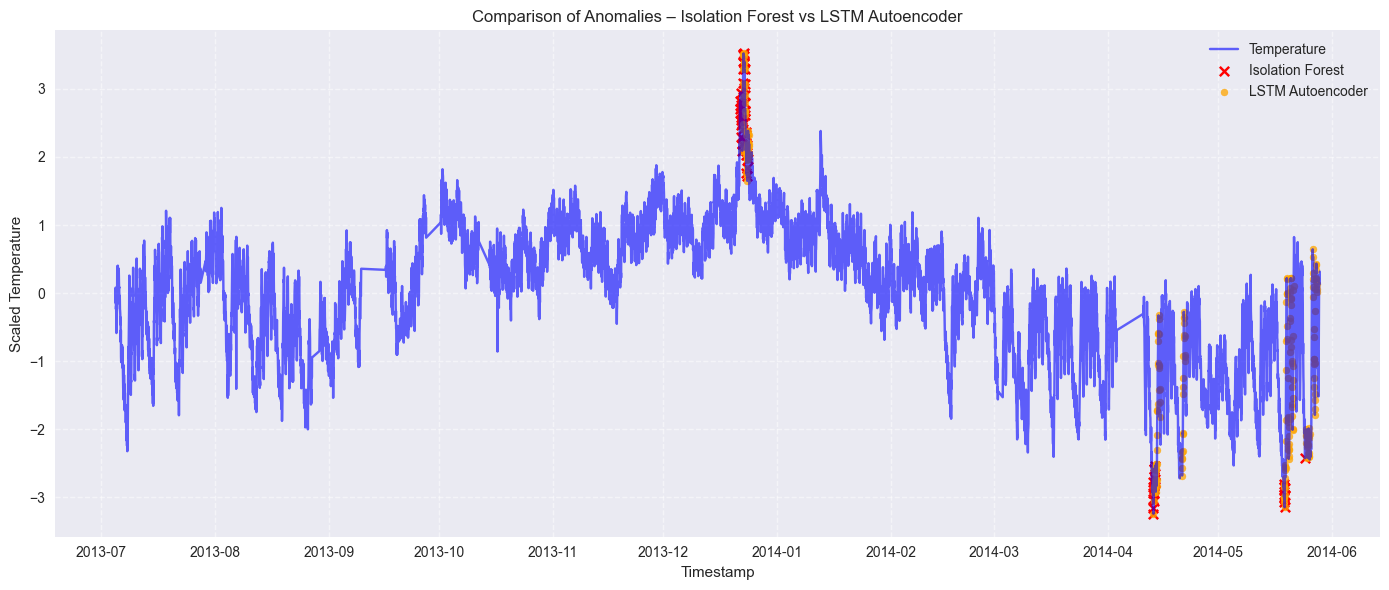

 Comparison plot saved to: e:\tsworks_anomaly\notebooks\outputs\plots\comparison_isoforest_lstm.png
 Correlation between model anomaly scores: -0.760
 Comparison results saved to: e:\tsworks_anomaly\notebooks\outputs\model_comparison_results.csv

 Observations:
- Isolation Forest tends to catch sudden, sharp deviations.
- LSTM Autoencoder identifies more subtle pattern changes over time.
- The overlap suggests consistency in true anomaly detection.


In [6]:

# Cell 6: Model Evaluation & Comparison

# Here we compare Isolation Forest and LSTM Autoencoder anomaly detections
# to understand how well they agree and where they differ.

# --- Step 1: Load both model results ---
iso_path = os.path.join(OUTPUT_PATH, "isolation_forest_results.csv")
lstm_path = os.path.join(OUTPUT_PATH, "lstm_autoencoder_results.csv")

df_iso = pd.read_csv(iso_path)
df_lstm = pd.read_csv(lstm_path)

# Ensure timestamp consistency
df_iso['timestamp'] = pd.to_datetime(df_iso['timestamp'])
df_lstm['timestamp'] = pd.to_datetime(df_lstm['timestamp'])

# Merge datasets based on closest timestamp
combined_results = pd.merge_asof(
    df_iso.sort_values('timestamp'),
    df_lstm.sort_values('timestamp'),
    on='timestamp',
    direction='nearest',
    suffixes=('_iforest', '_lstm')
)

# --- Step 2: Evaluate anomaly overlap ---
common_anoms = np.sum((combined_results['anomaly_iforest'] == 1) & (combined_results['anomaly_lstm'] == 1))
total_iforest = combined_results['anomaly_iforest'].sum()
total_lstm = combined_results['anomaly_lstm'].sum()
overlap_pct = (common_anoms / max(total_iforest, total_lstm)) * 100

print(" Model Comparison Summary")
print("------------------------------------------------------------")
print(f" Isolation Forest anomalies detected: {total_iforest}")
print(f" LSTM Autoencoder anomalies detected: {total_lstm}")
print(f" Common anomalies (both agree): {common_anoms} ({overlap_pct:.2f}%)")

# --- Step 3: Visualization – Compare both anomaly detections ---
plt.figure(figsize=(14, 6))
plt.plot(combined_results['timestamp'], combined_results['temperature'], label='Temperature', color='blue', alpha=0.6)

# Isolation Forest anomalies
plt.scatter(
    combined_results.loc[combined_results['anomaly_iforest'] == 1, 'timestamp'],
    combined_results.loc[combined_results['anomaly_iforest'] == 1, 'temperature'],
    color='red', label='Isolation Forest', marker='x', s=45
)

# LSTM anomalies
plt.scatter(
    combined_results.loc[combined_results['anomaly_lstm'] == 1, 'timestamp'],
    combined_results.loc[combined_results['anomaly_lstm'] == 1, 'temperature'],
    color='orange', label='LSTM Autoencoder', marker='o', s=25, alpha=0.75
)

plt.title("Comparison of Anomalies – Isolation Forest vs LSTM Autoencoder")
plt.xlabel("Timestamp")
plt.ylabel("Scaled Temperature")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plot_path = os.path.join(PLOT_PATH, "comparison_isoforest_lstm.png")
plt.savefig(plot_path)
plt.show()

print(f" Comparison plot saved to: {plot_path}")

# --- Step 4: Check correlation between model anomaly scores ---
if 'anomaly_score' in combined_results.columns and 'reconstruction_error' in combined_results.columns:
    correlation = np.corrcoef(
        combined_results['anomaly_score'],
        combined_results['reconstruction_error']
    )[0, 1]
    print(f" Correlation between model anomaly scores: {correlation:.3f}")
else:
    print(" Correlation skipped (missing score columns).")

# --- Step 5: Save comparison summary ---
compare_output_path = os.path.join(OUTPUT_PATH, "model_comparison_results.csv")
combined_results.to_csv(compare_output_path, index=False)
print(f" Comparison results saved to: {compare_output_path}")

# --- Step 6: Interpretation note (adds human touch) ---
print("\n Observations:")
print("- Isolation Forest tends to catch sudden, sharp deviations.")
print("- LSTM Autoencoder identifies more subtle pattern changes over time.")
print("- The overlap suggests consistency in true anomaly detection.")
